## Focus on 'congenital heart disease' network
* CHD genes are defined from this website: https://chdgene.victorchang.edu.au/
* There are 142 genes 

In [2]:
!date +%F

2025-02-27


In [3]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)

import random
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'pdf.fonttype':42}) 

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
numpy 1.26.4
pandas 2.2.1
scipy 1.12.0
matplotlib 3.8.3


### Load disease gene data  

In [4]:
CHD_genes_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/OpenTarget/CHD_Yang/chdgene_table.csv', sep=',')

### Load pySpade data

In [5]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [6]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [7]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

### Find out any targeted TFs that are CHD genes

In [8]:
CHD_TF = list(set(TF_region_df['TF'].values).intersection(CHD_genes_df['Gene']))

In [9]:
len(CHD_TF)

50

In [10]:
CHD_TF_region = list(TF_region_df[TF_region_df['TF'].isin(CHD_TF)].index)

In [12]:
gene_counts = global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].value_counts()
duplicate_genes = gene_counts[gene_counts > 4].index
CHD_TF_global_df = global_df[global_df['region'].isin(CHD_TF_region)][global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].isin(duplicate_genes)]

In [13]:
enr = gp.enrichr(gene_list=list(CHD_TF_global_df['gene_names'].values),
                   gene_sets=['BioCarta_2016', 'KEGG_2021_Human', 'Reactome_2022', 'WikiPathways_2019_Human'], 
#                   background=list(express_gene),
                   outdir=None,
                   cutoff=0.05)
coregulate_pathway = enr.results[enr.results['Adjusted P-value'] < 0.05]

In [14]:
coregulate_pathway['Pathway'] = coregulate_pathway['Gene_set'] + coregulate_pathway['Term']

/tmp/ipykernel_45612/2057974385.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coregulate_pathway['Pathway'] = coregulate_pathway['Gene_set'] + coregulate_pathway['Term']


In [15]:
index_list = []
value_list = []
for i, j in enumerate(coregulate_pathway.sort_values(by='Adjusted P-value').head(20)['Adjusted P-value']):
    index_list.append(i)
    value_list.append(-np.log10(j))

In [16]:
index_list.reverse()

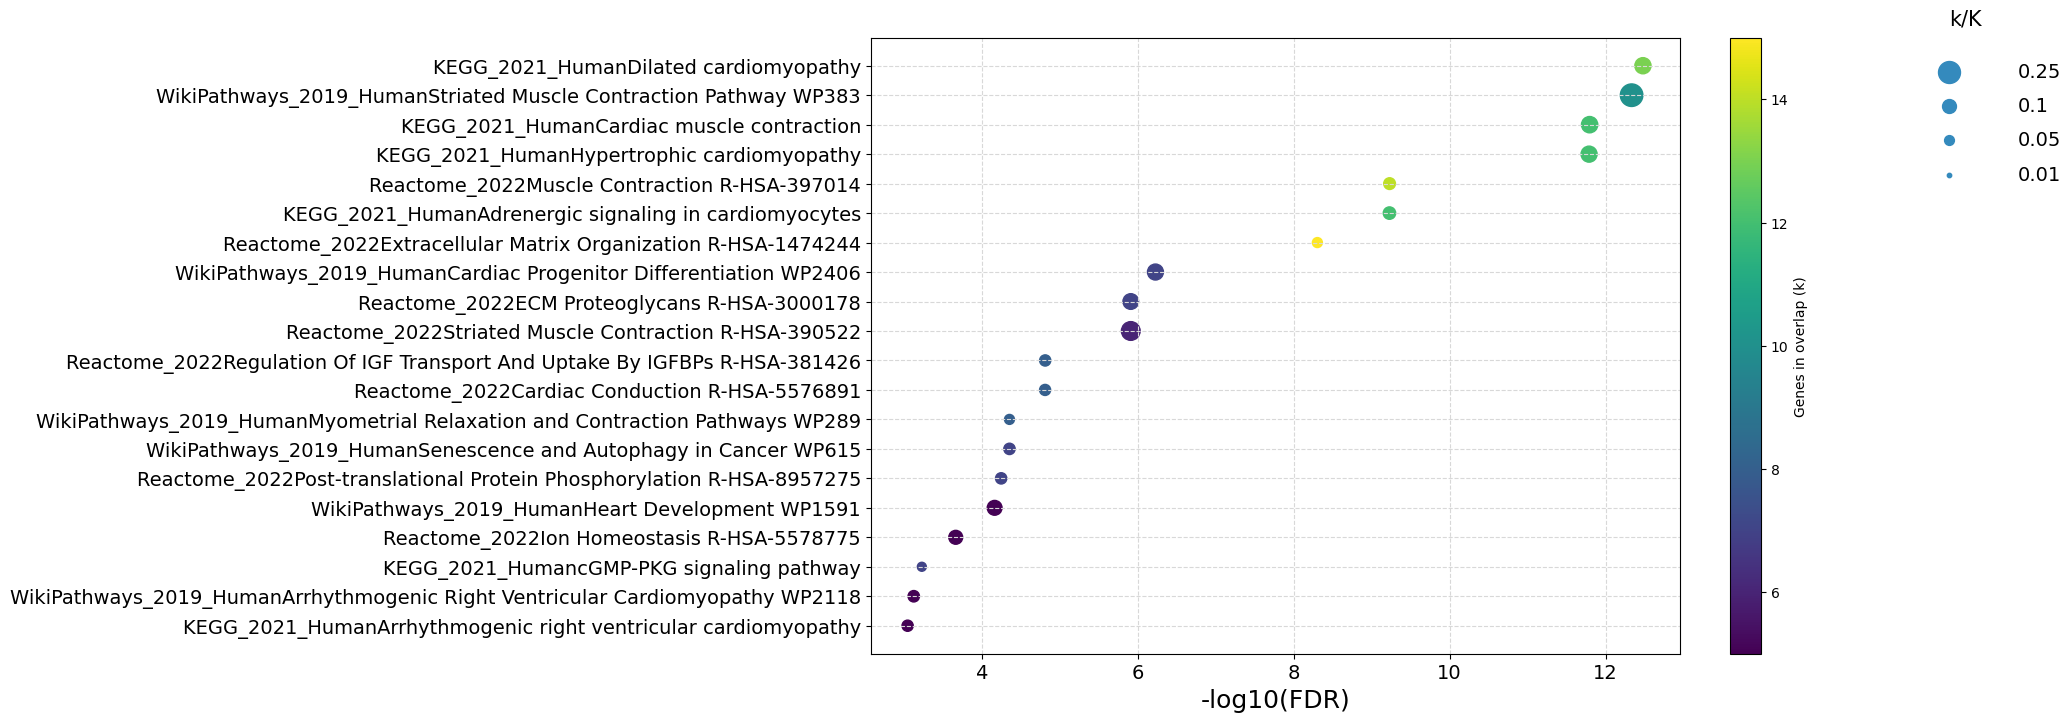

In [17]:
fig = plt.figure(figsize=(16,8))
gs = gridspec.GridSpec(nrows=1, ncols=11)
ax0 = fig.add_subplot(gs[:, 0:9])
ax0.grid(ls='--', color='#D8D8D8')
scatter = ax0.scatter(x=value_list, y=index_list, 
                        s=[int(i.split('/')[0])/int(i.split('/')[1])*1000 for i in coregulate_pathway.sort_values(by='Adjusted P-value').head(20)['Overlap']], 
                        c=[int(i.split('/')[0]) for i in coregulate_pathway.sort_values(by='Adjusted P-value').head(20)['Overlap'].values], 
                        cmap='viridis')
plt.yticks(ticks=index_list, labels=coregulate_pathway.sort_values(by='Adjusted P-value').head(20)['Pathway'].values, fontsize=14)
plt.xticks(fontsize=14)
ax0.set_xlabel('-log10(FDR)', fontsize=18)
plt.colorbar(scatter, ax=ax0, label='Genes in overlap (k)')
[ymin, ymax] = ax0.get_ylim()

ax1 = fig.add_subplot(gs[:,9])
ax1.set_ylim([0, 9])
size = [250, 100, 50, 10]
legend_text = ['0.25', '0.1', '0.05', '0.01']
y_list = [8.5, 8, 7.5, 7]
for i,size in enumerate(size):
    ax1.scatter(0.25, y_list[i], 
                s=size,
                c='#348ABD',
                marker='o')
    ax1.text(0.27, y_list[i],
            '%s'%(legend_text[i]),
            ha='left',
            va='center',
            fontsize = 14)
ax1.axis('off')
ax1.set_title("k/K", ha='left', va='bottom', fontsize = 15)
plt.show()
#plt.savefig('./Plot/20-2GSEA_barchart_CHDTF_coregulate_genes_v2.pdf', bbox_inches='tight')

### Generate the gene regulatory networks

In [18]:
global_df

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27573,31558319,38228,FITM1,chr14,2215538585,+,1,13,chrX:49042845-49043845,794,750,-12.332692,1.287023,-13.735282,1.285053,0.0,135.824176,105.693160
27574,31559427,47101,PECAM1,chr17,2555194338,-,0,16,chrX:49042845-49043845,794,750,-9.699542,16.178142,-11.238323,14.979639,0.0,3.247754,0.207479
27575,31579300,28022,DPP7,chr9,1673604089,-,0,8,chr19:52527153-52528153,811,750,-19.835936,0.714110,-19.482662,0.715293,0.0,186.828915,261.196259
27576,31582291,51353,ZNF808,chr19,2706938940,+,0,18,chr19:52527153-52528153,811,750,-18.799928,0.471482,-18.062261,0.474419,0.0,17.071369,35.994817


In [19]:
target_region_list = np.unique(global_df["region"])

In [53]:
min_regulating_gene = 3

G = nx.Graph()

valid_tf_region_list = []
local_hit_list = []
global_hit_list = []
skip_list = []
deg_num_list = []

for target_region in tqdm(target_region_list):
    primary_gene = annot_dict[target_region]
    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))

    if (re.search("^OR[0-9]",primary_gene) != None) or \
       (primary_gene == 'NonTarget'):
        skip_list.append(primary_gene)
        continue

    if (len(secondary_target_list) < min_regulating_gene):
        skip_list.append(primary_gene)
        continue
    valid_tf_region_list.append(target_region)
    G.add_node(primary_gene, type='TF', color=0, subset=0) 

print("Valid TFs",len(list(G.nodes())))
for target_region in tqdm(valid_tf_region_list):
    primary_gene = annot_dict[target_region]

    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))
    secondary_fc_list = list(set(global_df[global_df['region'] == target_region]["fc_by_rand_dist_cpm"].values))
    deg_num_list.append(len(secondary_target_list))
    for secondary_target,secondary_fc in zip(secondary_target_list,secondary_fc_list):
        global_hit_list.append(secondary_target)
        if not secondary_target in list(G.nodes()):
            G.add_node(secondary_target, type='gene', color=1, subset=2)
        
        if (primary_gene == secondary_target):
            continue
        if secondary_fc > 1:
            G.add_edge(primary_gene, secondary_target, regulation='red')
        else:
            G.add_edge(primary_gene, secondary_target, regulation='blue')


100%|██████████| 2082/2082 [00:03<00:00, 528.13it/s]


Valid TFs 1323


100%|██████████| 1397/1397 [00:05<00:00, 256.50it/s]


In [54]:
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

<Axes: ylabel='Count'>

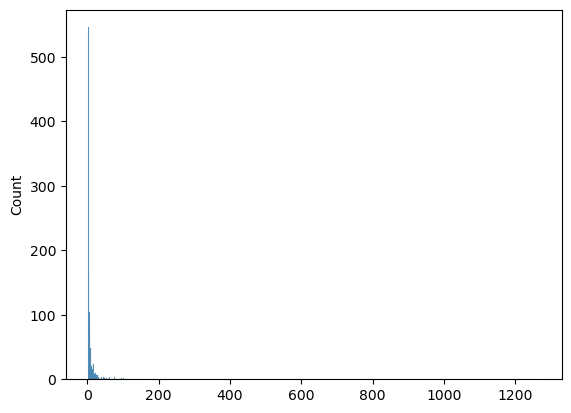

In [23]:
sns.histplot(deg_num_list)

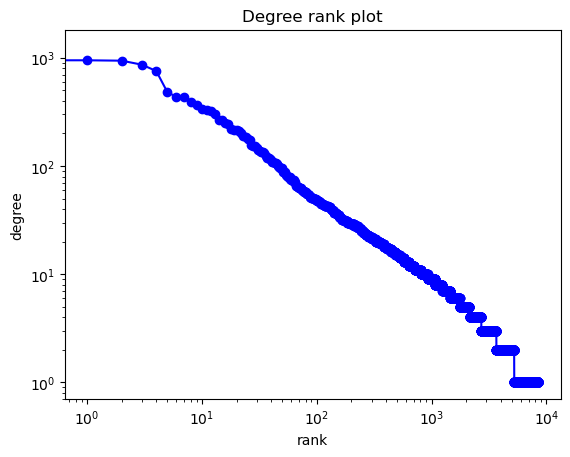

In [24]:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
plt.loglog(degree_sequence, 'b-', marker='o')
plt.title("Degree rank plot")
plt.ylabel("degree")
plt.xlabel("rank")
plt.show()

In [25]:
len(G.nodes())

8464

In [63]:
for i,gene_list in enumerate(list(nx.connected_components(G))):
    print(i,len(gene_list))

0 8438
1 3
2 4
3 4
4 4
5 4
6 4
7 3


In [64]:
largest_subgraph_nodes = list(nx.connected_components(G))[0]
largest_subgraph = G.subgraph(largest_subgraph_nodes).copy()

In [65]:
# remove miscullas graph
G = largest_subgraph

In [66]:
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

In [68]:
print(len(TF_nodes))
print(len(gene_nodes))

1316
7122


In [69]:
print(len(G.nodes))
print(len(G.edges))

8438
25615


In [73]:
print(len(G.edges)/len(TF_nodes))
print(len(G.edges)/len(gene_nodes))

19.464285714285715
3.5966020780679586


### Analyze TF-TF network

In [30]:
node_list = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
Between_TF_network = G.subgraph(node_list).copy()

print(len(Between_TF_network.nodes))
print(len(Between_TF_network.edges))
between_TF_prb = nx.density(Between_TF_network)
print(between_TF_prb)

1316
1579
0.0018248639153096722


In [71]:
print(len(Between_TF_network.edges)/len(Between_TF_network.nodes))

1.1998480243161094


In [31]:
tf_gene_edges = []
for u, v in G.edges():
    if (G.nodes[u].get('type') == 'TF' and G.nodes[v].get('type') == 'gene') or \
       (G.nodes[u].get('type') == 'gene' and G.nodes[v].get('type') == 'TF'):
        tf_gene_edges.append((u, v))

tf_gene_subgraph = nx.Graph()
tf_gene_subgraph.add_edges_from(tf_gene_edges)

TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

print(len(tf_gene_subgraph.nodes))
print(len(tf_gene_subgraph.edges))
TF_gene_prb = len(tf_gene_subgraph.edges)/(len(TF_nodes)*len(gene_nodes))
print(TF_gene_prb)

8438
24036
0.0025645096447584393


In [ ]:
print("edges/TF:",len(G.nodes))
print("edges/Gene:",len(G.edges))

In [32]:
len(tf_gene_subgraph.nodes)

8438

In [33]:
Between_TF_network

In [34]:
nx.density(Between_TF_network)

0.0018248639153096722

### Small-network propterty in Whole network

In [35]:
def generate_TF_random_graph(G,between_TF_prb,TF_gene_prb):
    G_random = nx.Graph()    
    
    TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
    gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]
    
    G_random.add_nodes_from(TF_nodes, type='TF', color=0, subset=0) 
    G_random.add_nodes_from(gene_nodes, type='gene', color=1, subset=2)
    
    #TF-TF nodes
    combis = combinations(TF_nodes,2)
    total_edges = []
    
    for tf_1,tf_2 in combis:
        if random.random() < between_TF_prb:
            total_edges.append([tf_1,tf_2])
    for TF_node in TF_nodes:
        for gene_node in gene_nodes:
            if random.random() < TF_gene_prb:
                total_edges.append([TF_node,gene_node])
    
    G_random.add_edges_from(total_edges)
    
    components = list(nx.connected_components(G_random))
    largest_component = max(components, key=len)
    G_random_sg = G_random.subgraph(largest_component).copy()
    
    return G_random_sg

def extract_TF_TF_graph(G):
    TF_node_list = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
    TF_TF_network = G.subgraph(TF_node_list).copy()
    
    components = list(nx.connected_components(TF_TF_network))
    largest_component = max(components, key=len)
    TF_TF_sg = G.subgraph(largest_component).copy()
    
    return TF_TF_sg
    

In [38]:
TF_TF_network = extract_TF_TF_graph(G)
print("Node:",len(TF_TF_network.nodes))
print("Edge:",len(TF_TF_network.edges))

avg_clustering = nx.average_clustering(G)
avg_shortest_path = nx.average_shortest_path_length(G)
print(avg_clustering,avg_shortest_path)

avg_TF_clustering = nx.average_clustering(TF_TF_network)
avg_TF_shortest_path = nx.average_shortest_path_length(TF_TF_network)
print(avg_TF_clustering,avg_TF_shortest_path)

Node: 716
Edge: 1533
0.030086844964307673 3.941690995680012
0.04534703491258856 4.12236590225417


In [40]:
n_rand=2
random.seed(10)

rand_clustering_list = []
rand_shortest_path_list = []

rand_TF_clustering_list = []
rand_TF_shortest_path_list = []

num_sub_gene_list = []

for _ in tqdm(range(n_rand)):
    rand_G = generate_TF_random_graph(G,between_TF_prb,TF_gene_prb)
    TF_TF_rand_network = extract_TF_TF_graph(rand_G)
    
    num_sub_gene_list.append(len(rand_G.nodes))

    rand_clustering = nx.average_clustering(rand_G)
    rand_shortest_path = nx.average_shortest_path_length(rand_G)
    print(rand_clustering,rand_shortest_path)
    
    rand_TF_clustering = nx.average_clustering(TF_TF_rand_network)
    rand_TF_shortest_path = nx.average_shortest_path_length(TF_TF_rand_network)
    print(rand_TF_clustering,rand_TF_shortest_path)
    
    rand_clustering_list.append(rand_clustering)
    rand_shortest_path_list.append(rand_shortest_path)
    
    rand_TF_clustering_list.append(rand_TF_clustering)
    rand_TF_shortest_path_list.append(rand_TF_shortest_path)

        
rand_clustering = np.sum(rand_clustering_list)/n_rand
rand_shortest_path = np.sum(rand_shortest_path_list)/n_rand

rand_TF_clustering = np.sum(rand_TF_clustering_list)/n_rand
rand_TF_shortest_path = np.sum(rand_TF_shortest_path_list)/n_rand

print(f"Clustering: {avg_clustering}, random: {rand_clustering}")
print(f"average_shortest_path_length: {avg_shortest_path}, random: {rand_shortest_path}")
print()
print(f"Clustering_TF: {avg_TF_clustering}, random: {rand_TF_clustering}")
print(f"average_shortest_path_length_TF: {avg_TF_shortest_path}, random: {rand_TF_shortest_path}")

  0%|          | 0/2 [00:00<?, ?it/s]

0.0014113086974812863 4.536525880177382


 50%|█████     | 1/2 [00:30<00:30, 30.32s/it]

0.002052545155993432 7.786065573770492
0.0008609828381666493 4.53806298687327


100%|██████████| 2/2 [01:01<00:00, 30.75s/it]

0.00025929127052722555 7.689548797301217
Clustering: 0.030086844964307673, random: 0.001136145767823968
average_shortest_path_length: 3.941690995680012, random: 4.537294433525326

Clustering_TF: 0.04534703491258856, random: 0.0011559182132603288
average_shortest_path_length_TF: 4.12236590225417, random: 7.737807185535855


In [43]:
sw_red_df = pd.DataFrame([[avg_clustering,avg_shortest_path],
                          [rand_clustering,rand_shortest_path]
                         ],index=["observed","random"],columns=["clustering_coef","average_shortest_path"])

sw_red_TF_df = pd.DataFrame([[avg_TF_clustering,avg_TF_shortest_path],
                          [rand_TF_clustering,rand_TF_shortest_path]
                         ],index=["observed","random"],columns=["clustering_coef","average_shortest_path"])

In [45]:
sw_red_df

,clustering_coef,average_shortest_path
observed,0.030087,3.941691
random,0.001136,4.537294


In [46]:
sw_red_TF_df

,clustering_coef,average_shortest_path
observed,0.045347,4.122366
random,0.001156,7.737807


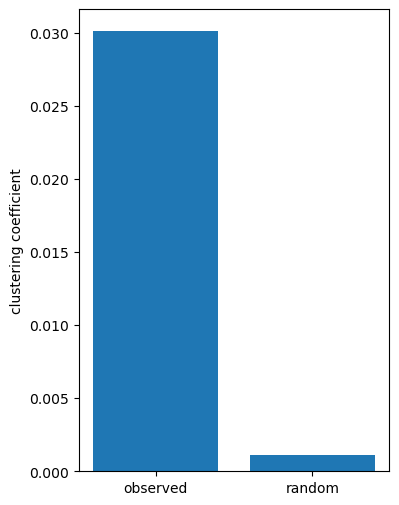

In [47]:
plt.subplots(figsize=(4,6))
plt.bar(x=sw_red_df.index,height=sw_red_df["clustering_coef"])
plt.ylabel("clustering coefficient")

plt.savefig("Plot/cluster_coef.pdf")

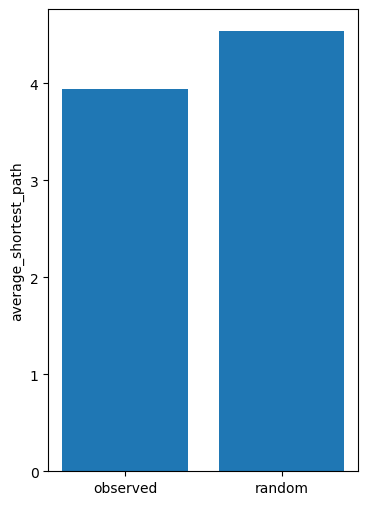

In [48]:
plt.subplots(figsize=(4,6))
plt.bar(x=sw_red_df.index,height=sw_red_df["average_shortest_path"])
plt.ylabel("average_shortest_path")

plt.savefig("Plot/ave_short_path.pdf")

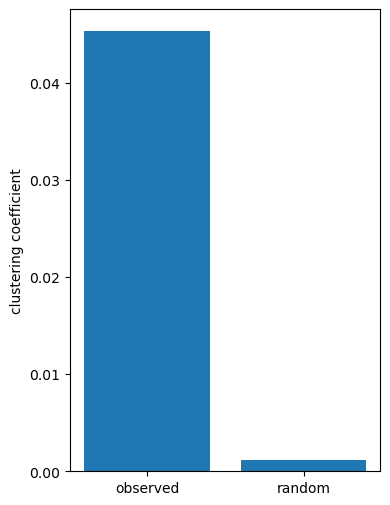

In [49]:
plt.subplots(figsize=(4,6))
plt.bar(x=sw_red_TF_df.index,height=sw_red_TF_df["clustering_coef"])
plt.ylabel("clustering coefficient")

plt.savefig("Plot/cluster_coef_TF.pdf")

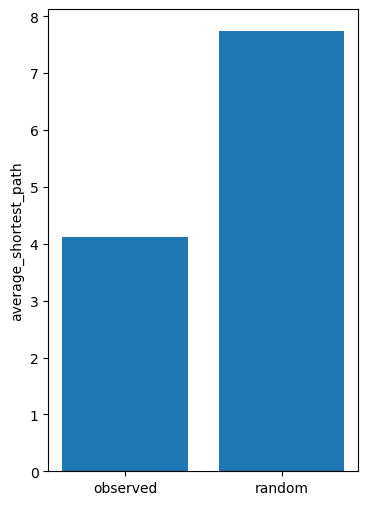

In [50]:
plt.subplots(figsize=(4,6))
plt.bar(x=sw_red_TF_df.index,height=sw_red_TF_df["average_shortest_path"])
plt.ylabel("average_shortest_path")

plt.savefig("Plot/ave_short_path_TF.pdf")

##### Visualization

In [ ]:
basic_cutoff_list = [n for n, d in G.degree() if d > 1]
large_node_list = [n for n, d in G.degree() if d > 10] #get nodes for key TFs

In [ ]:
print(len(basic_cutoff_list))
print(len(large_node_list))

In [ ]:
node_degree = np.array([float(G.degree(v)) for v in G if not v.startswith('chr')])
large_node_size = np.array([d for n, d in G.degree() if d > 10]) 
node_degree = np.clip(node_degree, 3, 20) #set the limit for plotting

In [ ]:
NonTF_CHD_genes = set(CHD_genes_df['Gene']).difference(set(TF_region_df['TF'].values))

In [ ]:
print(len(large_node_size))
print(len(node_degree))

In [ ]:
len(NonTF_CHD_genes)

In [ ]:
len(CHD_TF_region)

In [ ]:
nx.is_directed(G)